--- REPORTES DE CLASIFICACIÓN DETALLADOS ---

=== Modelo: Criterio GINI | Profundidad: 3 ===
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       0.33      1.00      0.50         5
       drugX       1.00      0.48      0.65        21
       drugY       0.96      1.00      0.98        22

    accuracy                           0.82        60
   macro avg       0.86      0.90      0.82        60
weighted avg       0.93      0.82      0.83        60

--------------------------------------------------
=== Modelo: Criterio GINI | Profundidad: 4 ===
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.96      1.00      0.98      

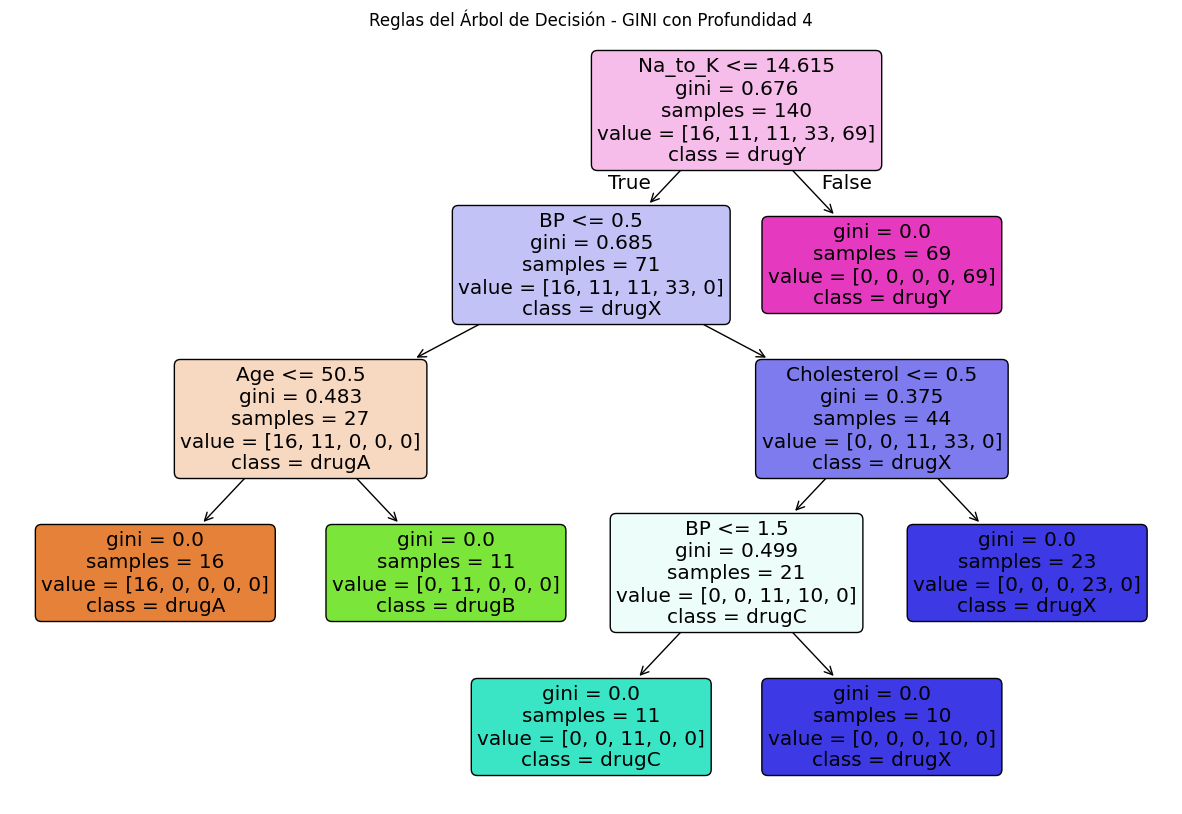


--- RECOMENDACIÓN MÉDICA PARA EL NUEVO PACIENTE ---
Medicamento a prescribir: drugC


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn import metrics, preprocessing
import warnings
warnings.filterwarnings('ignore')

# 1. Configurar la ruta exacta
os.chdir(r"C:\Users\Yamil\OneDrive\Escritorio\Escritorio\Yamil\EBAC (CIENCIA DE DATOS)\Bloque 4 Aprendizaje de máquina supervisado\MOD 5 Árboles de decisión\23.2 Implementa arboles")

# 2. Cargar la base de datos
df = pd.read_csv("drugs.csv")

# 3. CONVERSIÓN DE VARIABLES CUALITATIVAS (LabelEncoder)
feature_cols = ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
X = df[feature_cols].values
y = df['Drug'].values

# Sexo (F/M) -> (0/1)
Cod_Sex = preprocessing.LabelEncoder()
Cod_Sex.fit(['F', 'M'])
X[:, 1] = Cod_Sex.transform(X[:, 1])

# Presión (LOW, NORMAL, HIGH) -> (0, 1, 2)
Cod_BP = preprocessing.LabelEncoder()
Cod_BP.fit(['LOW', 'NORMAL', 'HIGH'])
X[:, 2] = Cod_BP.transform(X[:, 2])

# Colesterol (NORMAL, HIGH) -> (0, 1)
Cod_Chol = preprocessing.LabelEncoder()
Cod_Chol.fit(['NORMAL', 'HIGH'])
X[:, 3] = Cod_Chol.transform(X[:, 3])

# 4. Creación de grupos de entrenamiento y prueba (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=3)

# 5. EVALUACIÓN DE MODELOS: GINI VS ENTROPÍA (Distintas profundidades)
criterios = ['gini', 'entropy']
profundidades = [3, 4, 5]

best_acc = 0
best_model = None
best_name = ""

print("--- REPORTES DE CLASIFICACIÓN DETALLADOS ---\n")
for crit in criterios:
    for prof in profundidades:
        clf = DecisionTreeClassifier(criterion=crit, max_depth=prof, random_state=3)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        acc = metrics.accuracy_score(y_test, y_pred)
        print(f"=== Modelo: Criterio {crit.upper()} | Profundidad: {prof} ===")
        print(metrics.classification_report(y_test, y_pred))
        print("-" * 50)
        
        if acc > best_acc:
            best_acc = acc
            best_model = clf
            best_name = f"{crit.upper()} con Profundidad {prof}"

print(f"\nMEJOR MODELO SELECCIONADO: {best_name} (Exactitud: {best_acc:.4f})")

# 6. VISUALIZACIÓN DEL ÁRBOL
plt.figure(figsize=(15, 10))
plot_tree(best_model, feature_names=feature_cols, class_names=np.unique(y), filled=True, rounded=True)
plt.title(f"Reglas del Árbol de Decisión - {best_name}")
plt.savefig("arbol_drogas.png", facecolor='white', dpi=300, bbox_inches='tight')
plt.show()

# 7. PRONÓSTICO PARA EL PACIENTE NUEVO
# ---> YAMIL: INGRESA LOS VALORES DE LA IMAGEN 2 AQUÍ EN ESTE ORDEN <---
# Orden: [Edad, 'F' o 'M', 'LOW', 'NORMAL' o 'HIGH', 'NORMAL' o 'HIGH', Na_to_K]
nuevo_paciente = [[47, 'M', 'LOW', 'HIGH', 13.093]] # <--- REEMPLAZA ESTOS DATOS POR LOS DE TU IMAGEN

# Transformamos los datos del paciente nuevo para que el modelo los entienda
nuevo_paciente[0][1] = Cod_Sex.transform([nuevo_paciente[0][1]])[0]
nuevo_paciente[0][2] = Cod_BP.transform([nuevo_paciente[0][2]])[0]
nuevo_paciente[0][3] = Cod_Chol.transform([nuevo_paciente[0][3]])[0]

prediccion = best_model.predict(nuevo_paciente)
print(f"\n--- RECOMENDACIÓN MÉDICA PARA EL NUEVO PACIENTE ---")
print(f"Medicamento a prescribir: {prediccion[0]}")